In [1]:
from viz_helpers import *

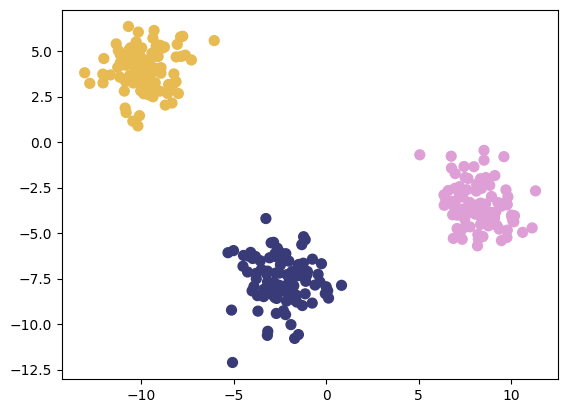

In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=300,
    n_features=2,
    centers=3,
    cluster_std=1.2,
)

plot_2d_clf_problem(X, y)

In [3]:
from dlfs.model import SequentialModel
from dlfs.layers import DenseLayer
from dlfs.modules import SequentialWrapper
from dlfs.activation import ReLU, Softmax
from dlfs.loss import CCE_Loss
from dlfs.optimizers import Optimizer_SGD, Optimizer_Adam

layers = [DenseLayer(2, 3), 
          ReLU(),
          DenseLayer(3, 3),
          ReLU(),
          DenseLayer(3, 3),
          Softmax()]

model = SequentialModel(layers=layers, loss_function=CCE_Loss(), optimizer=Optimizer_SGD(learning_rate=5e-2))

model.train(X, y, print_every=500, epochs=2000)

===== EPOCH : 0 ===== LOSS : 0.97374 =====
===== EPOCH : 500 ===== LOSS : 0.06468 =====
===== EPOCH : 1000 ===== LOSS : 0.02345 =====
===== EPOCH : 1500 ===== LOSS : 0.01381 =====
===== EPOCH : 2000 ===== LOSS : 0.00970 =====


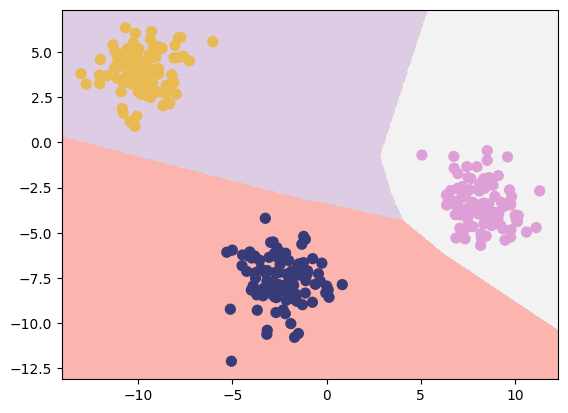

In [4]:
plot_2d_clf_problem(X, y, lambda x: np.argmax(model.predict(x), axis=-1))

In [5]:
model.forward(X)

Z1 = model.wrapper.layers[0].output.copy() # first dense layer
A1 = model.wrapper.layers[1].output.copy() # first dense + relu
Z2 = model.wrapper.layers[2].output.copy() # second dense
A2 = model.wrapper.layers[3].output.copy() # second dense + relu
Z3 = model.wrapper.layers[4].output.copy() # third dense
A3 = model.wrapper.layers[5].output.copy() # third dense + softmax

In [6]:
plot_3d_output(Z1, y, "2D → 2D via Linear Layer")

In [7]:
plot_3d_output(A1, y, "2D → 2D via Linear Layer + ReLU")

In [8]:
plot_3d_output(Z2, y, "2D → 2D via Linear Layer")

In [9]:
plot_3d_output(A2, y, "2D → 2D via Linear Layer + ReLU")

In [10]:
plot_3d_output(Z3, y, "2D → 2D via Linear Layer")

In [11]:
plot_3d_output(A3, y, "2D → 2D via Linear Layer")

In [12]:
print(np.round(A3[:10], decimals=3))

[[0.007 0.018 0.975]
 [0.007 0.018 0.975]
 [0.    0.997 0.003]
 [1.    0.    0.   ]
 [0.007 0.018 0.975]
 [0.007 0.018 0.975]
 [0.    0.997 0.003]
 [0.013 0.019 0.968]
 [0.    0.997 0.003]
 [0.007 0.018 0.975]]


In [13]:
print(np.round(A3[:10]))

[[0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [14]:
print(np.argmax(A3[:10], axis=-1))

[2 2 1 0 2 2 1 2 1 2]


In [15]:
print(y[:10])

[2 2 1 0 2 2 1 2 1 2]
